# Time-Series (ARDL) Disease-Severity Model: PPAC-B3, 2024

This notebook treats each (METHOD, SOIL, POINT) plot as a short time series and asks:
**given the history of a plot's VI trajectory and its own past disease severity, how
well can we estimate the current SEVERITY?**

This is an autoregressive distributed-lag (ARDL) framing:

```
SEVERITY_t ~ SEVERITY_{t-1}, SEVERITY_{t-2}, VI_t, VI_{t-1}, VI_{t-2}, VI trend features
```

Sections:
1. Data loading & panel construction with lag/trend features
2. Baselines: persistence and pure-AR (severity-only) models
3. Single-VI ARDL models (does adding one VI's history help over AR alone?)
4. Multivariate ARDL (all VIs + AR term)
5. Feature-importance breakdown by feature type (AR vs current VI vs VI lag vs VI trend)
6. Cross-combo summary and example trajectory plots

All four (METHOD x SOIL) combinations are run in parallel for comparison, rather than
picking one "best" combination up front.

**Caveats**:
- `08/03/2024` has no SEVERITY ratings and is dropped, same as in
  `method_comparison_PPAC-B3.ipynb`. The 7 remaining severity-bearing dates are
  `06/17, 07/11, 07/23, 08/13, 08/19, 09/01, 09/08`; note the 07/23 -> 08/13 gap is
  larger (~3 weeks) because 08/03 is excluded from the AR sequence.
- A raw flight from `07/17/2024` exists under `Data/PPAC-B3/071724_PPAC-B3` but was
  never processed into VI features / the combined file, so it is not part of this
  time series. If it gets processed later, this notebook can be re-run on the
  resulting 8-date series.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_excel("../combined_vi_stats_with_disease_PPAC-B3.xlsx")
df["DATE"] = pd.to_datetime(df["DATE"], format="%m%d%Y")

df_sev = df.dropna(subset=["SEVERITY"]).reset_index(drop=True)
assert df_sev.shape[0] == 3780

vi_mean_cols = [c for c in df.columns if c.endswith("_MEAN")]
methods = ["orthorectified", "whole"]
soils = ["YES", "NO"]

print(f"{len(vi_mean_cols)} mean VI columns:", vi_mean_cols)
print("Severity-bearing dates:", sorted(df_sev["DATE"].dt.strftime("%m/%d/%Y").unique()))

12 mean VI columns: ['NDVI_MEAN', 'NDRE_MEAN', 'EXG_MEAN', 'PSRI_MEAN', 'RDVI_MEAN', 'MCARI2_MEAN', 'RED_MEAN', 'GREEN_MEAN', 'BLUE_MEAN', 'REDEDGE_MEAN', 'NIR_MEAN', 'OSAVI_MEAN']
Severity-bearing dates: ['06/17/2024', '07/11/2024', '07/23/2024', '08/13/2024', '08/19/2024', '09/01/2024', '09/08/2024']


## Section 1 — Panel Construction with Lag/Trend Features

In [3]:
combo_data = {}
for method in methods:
    for soil in soils:
        sub = df_sev[(df_sev["METHOD"] == method) & (df_sev["SOIL"] == soil)]
        combo_data[(method, soil)] = (
            sub[["POINT", "DATE"] + vi_mean_cols + ["SEVERITY"]]
            .sort_values(["POINT", "DATE"])
            .reset_index(drop=True)
        )
        print(method, soil, combo_data[(method, soil)].shape)

orthorectified YES (945, 15)
orthorectified NO (945, 15)
whole YES (945, 15)
whole NO (945, 15)


In [4]:
# Adds SEVERITY_lag1/2, VI_lag1/2, VI_delta1 (1-step change), VI_slope2 (average
# 2-step change per step), then drops the first 2 timepoints per POINT where lags
# are undefined.
def build_panel(sub):
    sub = sub.sort_values(["POINT", "DATE"]).reset_index(drop=True)
    g = sub.groupby("POINT")

    out = sub.copy()
    out["SEVERITY_lag1"] = g["SEVERITY"].shift(1)
    out["SEVERITY_lag2"] = g["SEVERITY"].shift(2)

    for vi in vi_mean_cols:
        lag1 = g[vi].shift(1)
        lag2 = g[vi].shift(2)
        out[f"{vi}_lag1"] = lag1
        out[f"{vi}_lag2"] = lag2
        out[f"{vi}_delta1"] = sub[vi] - lag1
        out[f"{vi}_slope2"] = (sub[vi] - lag2) / 2

    return out.dropna().reset_index(drop=True)


panel_data = {key: build_panel(sub) for key, sub in combo_data.items()}
for key, panel in panel_data.items():
    print(key, panel.shape)

('orthorectified', 'YES') (675, 65)
('orthorectified', 'NO') (675, 65)
('whole', 'YES') (675, 65)
('whole', 'NO') (675, 65)


In [5]:
# Sanity check: lag1 for a given POINT/DATE should equal SEVERITY/VI at the
# previous flight date for the same POINT
check = panel_data[("orthorectified", "NO")]
sample_point = check["POINT"].iloc[0]
display(check[check["POINT"] == sample_point][["POINT", "DATE", "SEVERITY", "SEVERITY_lag1", "NDVI_MEAN", "NDVI_MEAN_lag1"]])

,POINT,DATE,SEVERITY,SEVERITY_lag1,NDVI_MEAN,NDVI_MEAN_lag1
0,1,2024-07-23,0.000000,0.000000,0.891109,0.867359
1,1,2024-08-13,0.039239,0.000000,0.871783,0.891109
2,1,2024-08-19,0.062889,0.039239,0.881212,0.871783
3,1,2024-09-01,0.206667,0.062889,0.835415,0.881212
4,1,2024-09-08,3.384130,0.206667,0.807274,0.835415


## Section 2 — Baselines: Persistence and Pure-AR Models

In [6]:
cv = GroupKFold(n_splits=5)

def make_models():
    return {
        "RF": RandomForestRegressor(n_estimators=500, random_state=42),
        "Ridge": Pipeline([("scaler", StandardScaler()), ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 13)))]),
    }

def evaluate(X, y, groups, model):
    rows = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        m = clone(model)
        m.fit(X[train_idx], y[train_idx])
        pred = m.predict(X[test_idx]).ravel()
        rows.append({
            "FOLD": fold_idx,
            "R2": r2_score(y[test_idx], pred),
            "RMSE": np.sqrt(mean_squared_error(y[test_idx], pred)),
            "MAE": mean_absolute_error(y[test_idx], pred),
        })
    return pd.DataFrame(rows)

In [7]:
# Persistence baseline: predict SEVERITY_t = SEVERITY_{t-1} directly, no fitting
persistence_rows = []
for (method, soil), panel in panel_data.items():
    y = panel["SEVERITY"].to_numpy()
    pred = panel["SEVERITY_lag1"].to_numpy()
    persistence_rows.append({
        "METHOD": method, "SOIL": soil, "MODEL": "Persistence",
        "R2": r2_score(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "MAE": mean_absolute_error(y, pred),
    })
persistence_df = pd.DataFrame(persistence_rows)
persistence_df

,METHOD,SOIL,MODEL,R2,RMSE,MAE
0,orthorectified,YES,Persistence,-0.03944,1.603659,0.790297
1,orthorectified,NO,Persistence,-0.03944,1.603659,0.790297
2,whole,YES,Persistence,-0.03944,1.603659,0.790297
3,whole,NO,Persistence,-0.03944,1.603659,0.790297


In [8]:
# AR(1) and AR(2): SEVERITY_t ~ SEVERITY lags only (no VI information)
ar_rows = []
for (method, soil), panel in panel_data.items():
    groups = panel["POINT"].to_numpy()
    y = panel["SEVERITY"].to_numpy()
    for ar_name, ar_cols in [("AR(1)", ["SEVERITY_lag1"]), ("AR(2)", ["SEVERITY_lag1", "SEVERITY_lag2"])]:
        X = panel[ar_cols].to_numpy()
        for model_name, model in make_models().items():
            res = evaluate(X, y, groups, model)
            res["METHOD"] = method
            res["SOIL"] = soil
            res["AR_ORDER"] = ar_name
            res["MODEL"] = model_name
            ar_rows.append(res)

ar_df = pd.concat(ar_rows, ignore_index=True)
ar_summary = ar_df.groupby(["METHOD", "SOIL", "AR_ORDER", "MODEL"])[["R2", "RMSE", "MAE"]].agg(["mean", "std"])
ar_summary

R2                RMSE            \
                                        mean       std      mean       std   
METHOD         SOIL AR_ORDER MODEL                                           
orthorectified NO   AR(1)    RF     0.939193  0.018773  0.382934  0.053215   
                             Ridge  0.897891  0.025143  0.497862  0.050725   
                    AR(2)    RF     0.951972  0.015056  0.340369  0.044353   
                             Ridge  0.908246  0.022497  0.471977  0.048603   
               YES  AR(1)    RF     0.939193  0.018773  0.382934  0.053215   
                             Ridge  0.897891  0.025143  0.497862  0.050725   
                    AR(2)    RF     0.951972  0.015056  0.340369  0.044353   
                             Ridge  0.908246  0.022497  0.471977  0.048603   
whole          NO   AR(1)    RF     0.939193  0.018773  0.382934  0.053215   
                             Ridge  0.897891  0.025143  0.497862  0.050725   
                    AR(2)    RF     0.951972  0.015056  0.340369  0.044353   
                             Ridge  0.908246  0.022497  0.471977  0.048603   
               YES  AR(1)    RF     0.939193  0.018773  0.382934  0.053215   
                             Ridge  0.897891  0.025143  0.497862  0.050725   
                    AR(2)    RF     0.951972  0.015056  0.340369  0.044353   
                             Ridge  0.908246  0.022497  0.471977  0.048603   

                                         MAE            
                                        mean       std  
METHOD         SOIL AR_ORDER MODEL                      
orthorectified NO   AR(1)    RF     0.177280  0.024590  
                             Ridge  0.248186  0.016664  
                    AR(2)    RF     0.146144  0.019335  
                             Ridge  0.273343  0.016689  
               YES  AR(1)    RF     0.177280  0.024590  
                             Ridge  0.248186  0.016664  
                    AR(2)    RF     0.146144  0.019335  
                             Ridge  0.273343  0.016689  
whole          NO   AR(1)    RF     0.177280  0.024590  
                             Ridge  0.248186  0.016664  
                    AR(2)    RF     0.146144  0.019335  
                             Ridge  0.273343  0.016689  
               YES  AR(1)    RF     0.177280  0.024590  
                             Ridge  0.248186  0.016664  
                    AR(2)    RF     0.146144  0.019335  
                             Ridge  0.273343  0.016689

## Section 3 — Single-VI ARDL Models

For each VI, the feature set is its current value, 1- and 2-step lags, and the
two trend features (`_delta1`, `_slope2`), plus the AR(2) severity terms
(`SEVERITY_lag1`, `SEVERITY_lag2`). Comparing each VI's R2 to the AR(2)-only R2 shows
how much that VI's history adds on top of the plot's own severity trajectory.

In [9]:
ardl_single_rows = []
for (method, soil), panel in panel_data.items():
    groups = panel["POINT"].to_numpy()
    y = panel["SEVERITY"].to_numpy()
    for vi in vi_mean_cols:
        feat_cols = ["SEVERITY_lag1", "SEVERITY_lag2", vi, f"{vi}_lag1", f"{vi}_lag2", f"{vi}_delta1", f"{vi}_slope2"]
        X = panel[feat_cols].to_numpy()
        for model_name, model in make_models().items():
            res = evaluate(X, y, groups, model)
            res["METHOD"] = method
            res["SOIL"] = soil
            res["VI"] = vi
            res["MODEL"] = model_name
            ardl_single_rows.append(res)

ardl_single_df = pd.concat(ardl_single_rows, ignore_index=True)
ardl_single_summary = ardl_single_df.groupby(["METHOD", "SOIL", "MODEL", "VI"])["R2"].mean().reset_index()
ardl_single_summary.head()

,METHOD,SOIL,MODEL,VI,R2
0,orthorectified,NO,RF,BLUE_MEAN,0.952068
1,orthorectified,NO,RF,EXG_MEAN,0.957607
2,orthorectified,NO,RF,GREEN_MEAN,0.956531
3,orthorectified,NO,RF,MCARI2_MEAN,0.958126
4,orthorectified,NO,RF,NDRE_MEAN,0.955152


In [10]:
# Compare each single-VI ARDL model to the AR(2)-only baseline (same METHOD/SOIL/MODEL)
ar2_r2 = (ar_df[ar_df["AR_ORDER"] == "AR(2)"]
          .groupby(["METHOD", "SOIL", "MODEL"])["R2"].mean()
          .reset_index().rename(columns={"R2": "AR2_R2"}))

ardl_single_summary = ardl_single_summary.merge(ar2_r2, on=["METHOD", "SOIL", "MODEL"])
ardl_single_summary["delta_R2_vs_AR2"] = ardl_single_summary["R2"] - ardl_single_summary["AR2_R2"]
ardl_single_summary.sort_values(["METHOD", "SOIL", "MODEL", "delta_R2_vs_AR2"], ascending=[True, True, True, False])

,METHOD,SOIL,MODEL,VI,R2,AR2_R2,delta_R2_vs_AR2
3,orthorectified,NO,RF,MCARI2_MEAN,0.958126,0.951972,0.006155
1,orthorectified,NO,RF,EXG_MEAN,0.957607,0.951972,0.005636
6,orthorectified,NO,RF,NIR_MEAN,0.956845,0.951972,0.004873
9,orthorectified,NO,RF,RDVI_MEAN,0.956759,0.951972,0.004787
2,orthorectified,NO,RF,GREEN_MEAN,0.956531,0.951972,0.004559
...,...,...,...,...,...,...,...
85,whole,YES,Ridge,EXG_MEAN,0.913661,0.908246,0.005415
90,whole,YES,Ridge,NIR_MEAN,0.912737,0.908246,0.004491
84,whole,YES,Ridge,BLUE_MEAN,0.912240,0.908246,0.003994
95,whole,YES,Ridge,RED_MEAN,0.909717,0.908246,0.001471


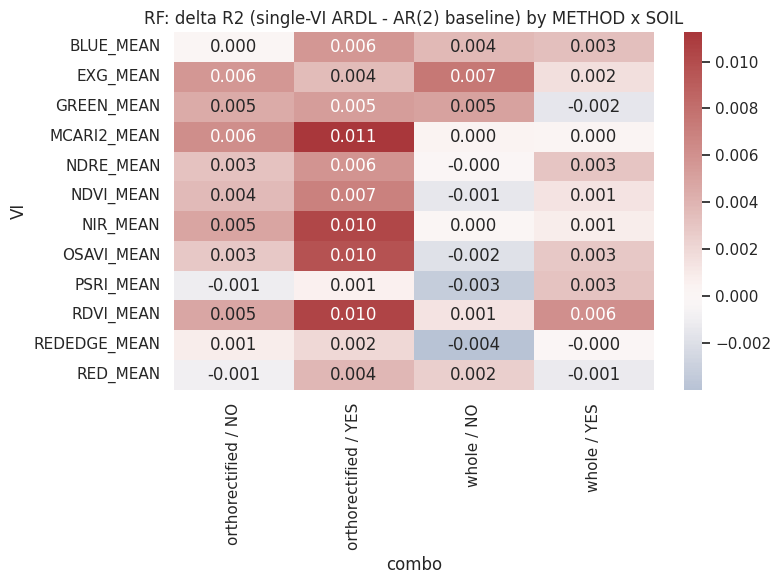

In [11]:
# Heatmap of delta R2 (single-VI ARDL minus AR(2)) for the RF model
heat = ardl_single_summary[ardl_single_summary["MODEL"] == "RF"].copy()
heat["combo"] = heat["METHOD"] + " / " + heat["SOIL"]
heat_pivot = heat.pivot(index="VI", columns="combo", values="delta_R2_vs_AR2")

plt.figure(figsize=(8, 6))
sns.heatmap(heat_pivot, annot=True, fmt=".3f", cmap="vlag", center=0)
plt.title("RF: delta R2 (single-VI ARDL - AR(2) baseline) by METHOD x SOIL")
plt.tight_layout()
plt.show()

## Section 4 — Multivariate ARDL (All VIs + AR Term)

In [12]:
feat_cols = ["SEVERITY_lag1", "SEVERITY_lag2"]
for vi in vi_mean_cols:
    feat_cols += [vi, f"{vi}_lag1", f"{vi}_lag2", f"{vi}_delta1", f"{vi}_slope2"]
print(f"{len(feat_cols)} features")

ardl_multi_rows = []
fitted_multi_models = {}  # (method, soil, model_name) -> list of (fold_idx, model, test_idx)

for (method, soil), panel in panel_data.items():
    X = panel[feat_cols].to_numpy()
    y = panel["SEVERITY"].to_numpy()
    groups = panel["POINT"].to_numpy()

    for model_name, model in make_models().items():
        fitted_multi_models[(method, soil, model_name)] = []
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
            m = clone(model)
            m.fit(X[train_idx], y[train_idx])
            pred = m.predict(X[test_idx]).ravel()
            ardl_multi_rows.append({
                "METHOD": method, "SOIL": soil, "MODEL": model_name, "FOLD": fold_idx,
                "R2": r2_score(y[test_idx], pred),
                "RMSE": np.sqrt(mean_squared_error(y[test_idx], pred)),
                "MAE": mean_absolute_error(y[test_idx], pred),
            })
            fitted_multi_models[(method, soil, model_name)].append((fold_idx, m, test_idx))

ardl_multi_df = pd.DataFrame(ardl_multi_rows)
ardl_multi_df.groupby(["METHOD", "SOIL", "MODEL"])[["R2", "RMSE", "MAE"]].agg(["mean", "std"])

62 features


R2                RMSE                 MAE  \
                               mean       std      mean       std      mean   
METHOD         SOIL MODEL                                                     
orthorectified NO   RF     0.953658  0.020314  0.329333  0.071125  0.140014   
                    Ridge  0.935892  0.028844  0.388723  0.078458  0.210762   
               YES  RF     0.960206  0.016279  0.307361  0.060357  0.130334   
                    Ridge  0.947726  0.018122  0.353316  0.055921  0.204598   
whole          NO   RF     0.952109  0.024711  0.333186  0.079195  0.140282   
                    Ridge  0.939467  0.024320  0.378057  0.071953  0.215874   
               YES  RF     0.950348  0.018125  0.343563  0.060195  0.140863   
                    Ridge  0.943249  0.020783  0.367507  0.061602  0.215508   

                                     
                                std  
METHOD         SOIL MODEL            
orthorectified NO   RF     0.029415  
                    Ridge  0.036693  
               YES  RF     0.023515  
                    Ridge  0.029073  
whole          NO   RF     0.034974  
                    Ridge  0.042161  
               YES  RF     0.024571  
                    Ridge  0.037351

## Section 5 — Feature Importance by Feature Type

For the multivariate RF models, average `feature_importances_` across folds and
group features into four types: the AR (severity-lag) terms, each VI's current value,
each VI's 1-/2-step lags, and each VI's trend features (`_delta1`, `_slope2`). Summing
importance within each type shows whether VI *history/trend* adds information beyond
the current VI value and the AR term.

In [13]:
def feature_type(col):
    if col.startswith("SEVERITY_lag"):
        return "AR (severity lag)"
    if col.endswith("_lag1") or col.endswith("_lag2"):
        return "VI lag"
    if col.endswith("_delta1") or col.endswith("_slope2"):
        return "VI trend"
    return "VI current"


importance_rows = []
for (method, soil) in combo_data:
    rf_models = [m for _, m, _ in fitted_multi_models[(method, soil, "RF")]]
    imp = np.mean([m.feature_importances_ for m in rf_models], axis=0)
    for col, val in zip(feat_cols, imp):
        importance_rows.append({
            "METHOD": method, "SOIL": soil, "FEATURE": col,
            "TYPE": feature_type(col), "IMPORTANCE": val,
        })

importance_df = pd.DataFrame(importance_rows)
type_importance = importance_df.groupby(["METHOD", "SOIL", "TYPE"])["IMPORTANCE"].sum().reset_index()
type_importance

,METHOD,SOIL,TYPE,IMPORTANCE
0,orthorectified,NO,AR (severity lag),0.125472
1,orthorectified,NO,VI current,0.612006
2,orthorectified,NO,VI lag,0.150183
3,orthorectified,NO,VI trend,0.112339
4,orthorectified,YES,AR (severity lag),0.167979
5,orthorectified,YES,VI current,0.514855
6,orthorectified,YES,VI lag,0.027645
7,orthorectified,YES,VI trend,0.289521
8,whole,NO,AR (severity lag),0.160799
9,whole,NO,VI current,0.609486


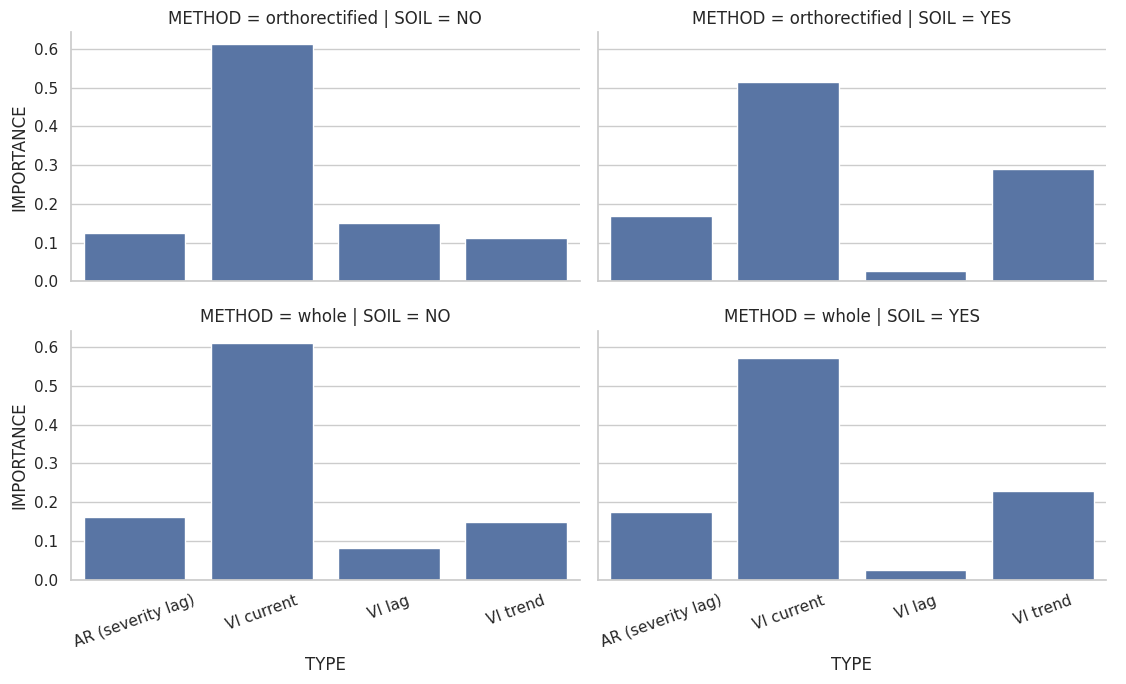

In [14]:
# Bar chart of summed importance by feature type, faceted by METHOD x SOIL
g = sns.catplot(
    data=type_importance, x="TYPE", y="IMPORTANCE", col="SOIL", row="METHOD",
    kind="bar", height=3.5, aspect=1.6,
    order=["AR (severity lag)", "VI current", "VI lag", "VI trend"],
)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [15]:
# Top 10 individual features by importance, per combo
for (method, soil) in combo_data:
    top = (importance_df[(importance_df["METHOD"] == method) & (importance_df["SOIL"] == soil)]
           .sort_values("IMPORTANCE", ascending=False).head(10))
    print(f"\n{method} / {soil}")
    print(top[["FEATURE", "TYPE", "IMPORTANCE"]].to_string(index=False))


orthorectified / YES
           FEATURE              TYPE  IMPORTANCE
     SEVERITY_lag1 AR (severity lag)    0.160329
 OSAVI_MEAN_slope2          VI trend    0.145443
        OSAVI_MEAN        VI current    0.120574
       MCARI2_MEAN        VI current    0.112517
          NIR_MEAN        VI current    0.112433
         RDVI_MEAN        VI current    0.097978
  NDRE_MEAN_slope2          VI trend    0.057101
         NDVI_MEAN        VI current    0.039999
         NDRE_MEAN        VI current    0.021545
MCARI2_MEAN_slope2          VI trend    0.021379

orthorectified / NO
         FEATURE              TYPE  IMPORTANCE
     MCARI2_MEAN        VI current    0.180914
      OSAVI_MEAN        VI current    0.134732
   SEVERITY_lag1 AR (severity lag)    0.121778
        NIR_MEAN        VI current    0.111481
       RDVI_MEAN        VI current    0.100071
       NDVI_MEAN        VI current    0.048931
NDRE_MEAN_slope2          VI trend    0.047772
   RED_MEAN_lag1            VI lag    0.04

## Section 6 — Cross-Combo Summary and Example Trajectories

In [16]:
# Summary table: mean R2 for persistence, AR(2), best single-VI ARDL, multivariate ARDL
summary_rows = []
for (method, soil) in combo_data:
    persistence_r2 = persistence_df[(persistence_df.METHOD == method) & (persistence_df.SOIL == soil)]["R2"].iloc[0]
    for model_name in ["RF", "Ridge"]:
        ar2_val = ar_df[(ar_df.METHOD == method) & (ar_df.SOIL == soil) & (ar_df.AR_ORDER == "AR(2)") & (ar_df.MODEL == model_name)]["R2"].mean()
        best_single = ardl_single_summary[(ardl_single_summary.METHOD == method) & (ardl_single_summary.SOIL == soil) & (ardl_single_summary.MODEL == model_name)]["R2"].max()
        multi_val = ardl_multi_df[(ardl_multi_df.METHOD == method) & (ardl_multi_df.SOIL == soil) & (ardl_multi_df.MODEL == model_name)]["R2"].mean()
        summary_rows.append({
            "METHOD": method, "SOIL": soil, "MODEL": model_name,
            "Persistence_R2": persistence_r2,
            "AR2_R2": ar2_val,
            "Best_SingleVI_ARDL_R2": best_single,
            "Multivariate_ARDL_R2": multi_val,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,METHOD,SOIL,MODEL,Persistence_R2,AR2_R2,Best_SingleVI_ARDL_R2,Multivariate_ARDL_R2
0,orthorectified,YES,RF,-0.03944,0.951972,0.963217,0.960206
1,orthorectified,YES,Ridge,-0.03944,0.908246,0.928869,0.947726
2,orthorectified,NO,RF,-0.03944,0.951972,0.958126,0.953658
3,orthorectified,NO,Ridge,-0.03944,0.908246,0.925145,0.935892
4,whole,YES,RF,-0.03944,0.951972,0.958090,0.950348
5,whole,YES,Ridge,-0.03944,0.908246,0.924561,0.943249
6,whole,NO,RF,-0.03944,0.951972,0.959454,0.952109
7,whole,NO,Ridge,-0.03944,0.908246,0.919528,0.939467


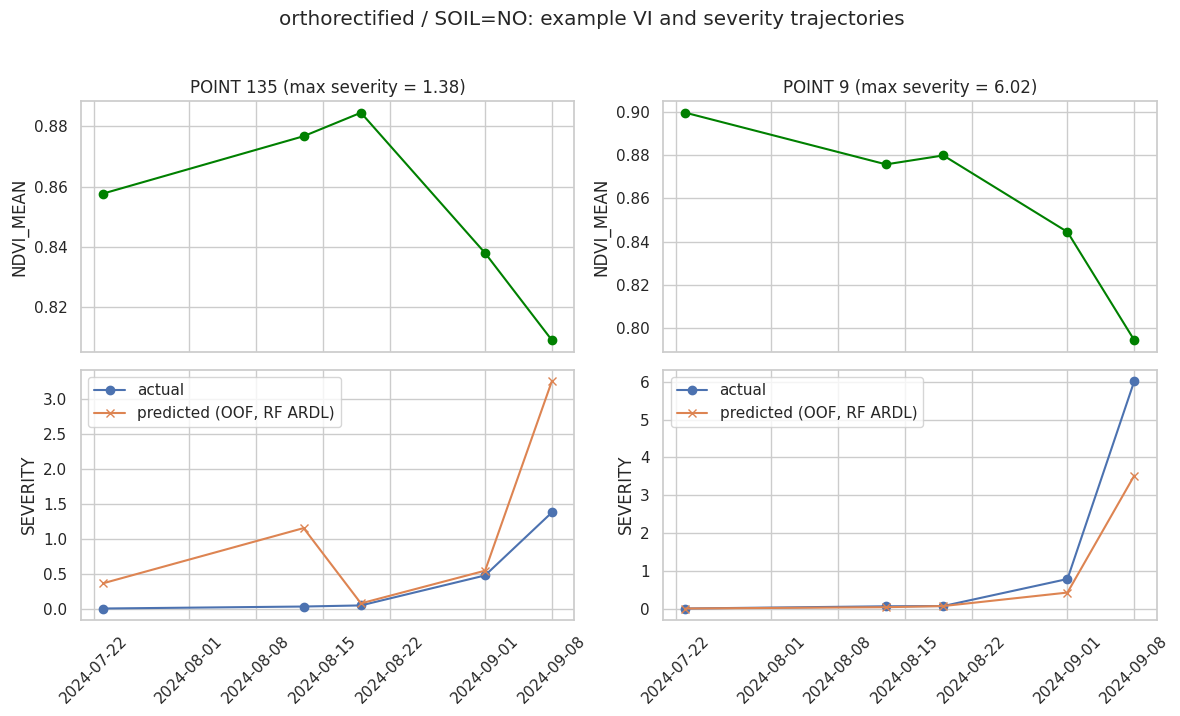

In [17]:
# Out-of-fold predictions from the multivariate ARDL model (Section 4 CV scheme)
def oof_predictions(method, soil, model_name, panel):
    X = panel[feat_cols].to_numpy()
    y = panel["SEVERITY"].to_numpy()
    groups = panel["POINT"].to_numpy()
    preds = np.full(len(y), np.nan)
    for _, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        m = clone(make_models()[model_name])
        m.fit(X[train_idx], y[train_idx])
        preds[test_idx] = m.predict(X[test_idx]).ravel()
    return preds


# Example trajectories for orthorectified / SOIL=NO: lowest- and highest-severity plots
panel = panel_data[("orthorectified", "NO")].copy()
panel["SEVERITY_pred_RF"] = oof_predictions("orthorectified", "NO", "RF", panel)

max_sev = panel.groupby("POINT")["SEVERITY"].max()
low_point, high_point = max_sev.idxmin(), max_sev.idxmax()

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for col, point in enumerate([low_point, high_point]):
    sub = panel[panel["POINT"] == point].sort_values("DATE")
    axes[0, col].plot(sub["DATE"], sub["NDVI_MEAN"], marker="o", color="green")
    axes[0, col].set_title(f"POINT {point} (max severity = {max_sev[point]:.2f})")
    axes[0, col].set_ylabel("NDVI_MEAN")

    axes[1, col].plot(sub["DATE"], sub["SEVERITY"], marker="o", label="actual")
    axes[1, col].plot(sub["DATE"], sub["SEVERITY_pred_RF"], marker="x", label="predicted (OOF, RF ARDL)")
    axes[1, col].set_ylabel("SEVERITY")
    axes[1, col].legend()
    axes[1, col].tick_params(axis="x", rotation=45)

fig.suptitle("orthorectified / SOIL=NO: example VI and severity trajectories", y=1.02)
plt.tight_layout()
plt.show()

## Summary

- **Persistence (`SEVERITY_t = SEVERITY_{t-1}`) performs poorly** (R2 = -0.04):
  severity grows roughly exponentially through the season, so naively carrying
  forward the last reading systematically under-predicts later-season severity.
- **AR(2) alone (RF) already explains ~95% of the variance** (R2 ~0.95) once a model
  is allowed to learn the right scaling/curvature from `SEVERITY_lag1`/`SEVERITY_lag2`
  — i.e. a plot's own disease trajectory is the dominant signal.
- **Adding VI information (single-VI or multivariate ARDL) gives only a small
  additional lift** over AR(2) (delta R2 typically +0.002 to +0.012 for RF). The
  best single VIs tend to be MCARI2/EXG/NIR/RDVI/OSAVI, consistent with the
  cross-sectional analysis in `method_comparison_PPAC-B3.ipynb`.
- In the feature-importance breakdown, **current-timepoint VI value dominates**,
  followed by the AR severity-lag term; VI *lag* and *trend* (delta/slope) features
  contribute comparatively little on their own — though `SOIL=YES` combos show a
  visibly larger "VI trend" share (~0.23-0.29) than `SOIL=NO` (~0.11-0.15), and
  `*_slope2` trend features for OSAVI/NDRE/MCARI2 do appear among each combo's top-10
  features.
- AR(2), Persistence, and the AR-only models give **identical results across all 4
  (METHOD, SOIL) combos** — expected, since SEVERITY itself doesn't depend on the VI
  extraction method.

**Takeaway**: for nowcasting current severity, a plot's own recent severity history
is by far the strongest signal; VI history/trend is a secondary, modest refinement
rather than a primary driver in this dataset.